# GNN sui jet constituents

Questo notebook implementa una prima pipeline **GNN-like in PyTorch puro** per Emerging Jets.

Idea:

- ogni jet è visto come un grafo;
- ogni nodo è una traccia associata al jet;
- gli archi sono costruiti con k-nearest neighbors nello spazio `(deta, dphi)`;
- una rete tipo EdgeConv aggiorna le tracce usando le tracce vicine;
- il modello ricostruisce sia le feature delle tracce sia le feature globali del jet;
- lo score di anomalia è il reconstruction error.

Il notebook può:

1. usare dataset già preprocessati `.npz`, se presenti;
2. altrimenti crearli direttamente dai file `.h5` originali;
3. allenare una GNN Autoencoder;
4. calcolare ROC/AUC su background vs signal;
5. fare controlli diagnostici train vs test background.

Questa versione non usa PyTorch Geometric: è tutta in PyTorch standard.

## 1. Import e GPU

In [1]:
from pathlib import Path
import json
import numpy as np
import h5py
import yaml
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
torch.manual_seed(42)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.12.0+cu126
CUDA available: True
CUDA version: 12.6
GPU count: 1
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 2. Path e configurazione

In [2]:
RAW_DIR = Path(".")
PROCESSED_DIR = Path("processed_gnn")
OUTPUT_DIR = Path("outputs_gnn")

PROCESSED_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

raw_files = {
    "val": RAW_DIR / "pp_output_val.h5",
    "test_background": RAW_DIR / "pp_output_test_background.h5",
    "test_signal": RAW_DIR / "pp_output_test_signal.h5",
}

norm_path = RAW_DIR / "norm_dict.yaml"

processed_files = {
    "val": PROCESSED_DIR / "processed_gnn_jet_track_val.npz",
    "test_background": PROCESSED_DIR / "processed_gnn_jet_track_test_background.npz",
    "test_signal": PROCESSED_DIR / "processed_gnn_jet_track_test_signal.npz",
}

for name, path in raw_files.items():
    print(name, "raw ->", path, "exists:", path.exists())

print("norm_dict ->", norm_path, "exists:", norm_path.exists())

for name, path in processed_files.items():
    print(name, "processed ->", path, "exists:", path.exists())

val raw -> pp_output_val.h5 exists: True
test_background raw -> pp_output_test_background.h5 exists: True
test_signal raw -> pp_output_test_signal.h5 exists: True
norm_dict -> norm_dict.yaml exists: True
val processed -> processed_gnn\processed_gnn_jet_track_val.npz exists: False
test_background processed -> processed_gnn\processed_gnn_jet_track_test_background.npz exists: False
test_signal processed -> processed_gnn\processed_gnn_jet_track_test_signal.npz exists: False


## 3. Feature usate

In [3]:
# Importante:
# - isDisplaced è label, quindi esclusa.
# - salt_pdisp e isTagged sono esclusi perché possono introdurre leakage.
# - displacedPtFraction è disattivata di default perché è una feature molto vicina al concetto di displacement.

USE_DISPLACED_PT_FRACTION = False

jet_features_base = [
    "pt",
    "eta",
    "mass",
    "energy",
    "Qw_clusterSoftDrop",
    "C2_clusterSoftDrop",
    "D2_clusterSoftDrop",
    "Tau1_clusterSoftDrop",
    "Tau2_clusterSoftDrop",
    "Tau3_clusterSoftDrop",
    "Tau21_clusterSoftDrop",
    "Tau32_clusterSoftDrop",
    "ECF1_clusterSoftDrop",
    "ECF2_clusterSoftDrop",
]

if USE_DISPLACED_PT_FRACTION:
    jet_features = [
        "pt",
        "eta",
        "mass",
        "energy",
        "displacedPtFraction",
        "Qw_clusterSoftDrop",
        "C2_clusterSoftDrop",
        "D2_clusterSoftDrop",
        "Tau1_clusterSoftDrop",
        "Tau2_clusterSoftDrop",
        "Tau3_clusterSoftDrop",
        "Tau21_clusterSoftDrop",
        "Tau32_clusterSoftDrop",
        "ECF1_clusterSoftDrop",
        "ECF2_clusterSoftDrop",
    ]
else:
    jet_features = jet_features_base

track_features = [
    "d0",
    "z0SinTheta",
    "dphi",
    "deta",
    "pt_log1p",
    "radiusOfFirstHit",
    "numberOfPixelHits",
    "numberOfSCTHits",
    "numberOfSCTHoles",
    "numberOfInnermostPixelLayerHits",
    "numberOfPixelSharedHits",
    "numberOfSCTSharedHits",
]

print("USE_DISPLACED_PT_FRACTION:", USE_DISPLACED_PT_FRACTION)
print("jet_features:", jet_features)
print("track_features:", track_features)
print("n jet features:", len(jet_features))
print("n track features:", len(track_features))

coord_feature_names = ["deta", "dphi"]
coord_indices = [track_features.index(name) for name in coord_feature_names]
print("Graph coordinates:", coord_feature_names, coord_indices)

USE_DISPLACED_PT_FRACTION: False
jet_features: ['pt', 'eta', 'mass', 'energy', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']
track_features: ['d0', 'z0SinTheta', 'dphi', 'deta', 'pt_log1p', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']
n jet features: 14
n track features: 12
Graph coordinates: ['deta', 'dphi'] [3, 2]


## 4. Funzioni preprocessing da HDF5 a NPZ

In [4]:
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)


def get_fields(file_path, dataset_name):
    with h5py.File(file_path, "r") as f:
        return set(f[dataset_name].dtype.names)


def get_norm_stats(norm_dict, object_type, feature, fallback_values=None, fallback_mask=None):
    if object_type in norm_dict and feature in norm_dict[object_type]:
        mean = float(norm_dict[object_type][feature]["mean"])
        std = float(norm_dict[object_type][feature]["std"])
        std = max(std, 1e-8)
        return mean, std, "norm_dict"

    if fallback_values is None:
        raise KeyError(f"{object_type}.{feature} non trovato in norm_dict e fallback assente")

    if fallback_mask is not None:
        values = fallback_values[fallback_mask]
    else:
        values = fallback_values

    mean = float(np.nanmean(values))
    std = float(np.nanstd(values))
    std = max(std, 1e-8)
    return mean, std, "computed"


def build_jet_track_dataset(file_path, jet_features, track_features, norm_dict, max_jets=None, verbose=True):
    file_path = Path(file_path)

    if verbose:
        print("\n" + "=" * 100)
        print("Processing:", file_path)
        print("=" * 100)

    with h5py.File(file_path, "r") as f:
        jets = f["jets"]
        tracks = f["tracks"]

        n_total = jets.shape[0]
        n = n_total if max_jets is None else min(max_jets, n_total)
        n_tracks = tracks.shape[1]

        if verbose:
            print("Total jets:", n_total)
            print("Jets used:", n)
            print("Tracks per jet:", n_tracks)

        track_mask = np.asarray(tracks["valid"][:n], dtype=bool)

        X_jets = np.empty((n, len(jet_features)), dtype=np.float32)
        norm_stats_jets = {}

        for i, feat in enumerate(jet_features):
            x = np.asarray(jets[feat][:n], dtype=np.float32)
            mean, std, source = get_norm_stats(norm_dict, "jets", feat, fallback_values=x)
            x = (x - mean) / std
            np.nan_to_num(x, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
            X_jets[:, i] = x
            norm_stats_jets[feat] = {"mean": mean, "std": std, "source": source}

        X_tracks = np.empty((n, n_tracks, len(track_features)), dtype=np.float32)
        norm_stats_tracks = {}

        for i, feat in enumerate(track_features):
            x = np.asarray(tracks[feat][:n], dtype=np.float32)
            mean, std, source = get_norm_stats(
                norm_dict,
                "tracks",
                feat,
                fallback_values=x,
                fallback_mask=track_mask,
            )
            x = (x - mean) / std
            np.nan_to_num(x, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
            x[~track_mask] = 0.0
            X_tracks[:, :, i] = x
            norm_stats_tracks[feat] = {"mean": mean, "std": std, "source": source}

        metadata = {}
        for key in ["isDisplaced", "flavour_label", "mcEventWeight", "eventNumber"]:
            if key in jets.dtype.names:
                metadata[key] = np.asarray(jets[key][:n])

        filename = file_path.name.lower()
        if "background" in filename:
            y = np.zeros(n, dtype=np.int64)
        elif "signal" in filename:
            y = np.ones(n, dtype=np.int64)
        elif "isDisplaced" in metadata:
            y = metadata["isDisplaced"].astype(np.int64)
        else:
            y = None

    if verbose:
        print("X_jets:", X_jets.shape, X_jets.dtype)
        print("X_tracks:", X_tracks.shape, X_tracks.dtype)
        print("track_mask:", track_mask.shape, track_mask.dtype)
        print("finite X_jets:", np.isfinite(X_jets).all())
        print("finite X_tracks:", np.isfinite(X_tracks).all())
        print("invalid tracks zero:", np.allclose(X_tracks[~track_mask], 0.0))
        if y is not None:
            print("y:", np.unique(y, return_counts=True))
        if "isDisplaced" in metadata:
            print("meta_isDisplaced:", np.unique(metadata["isDisplaced"], return_counts=True))

    norm_stats = {"jets": norm_stats_jets, "tracks": norm_stats_tracks}
    return X_jets, X_tracks, track_mask, metadata, y, norm_stats


def save_processed_dataset(out_path, X_jets, X_tracks, track_mask, jet_features, track_features, metadata=None, y=None, norm_stats=None):
    payload = {
        "X_jets": X_jets.astype(np.float32),
        "X_tracks": X_tracks.astype(np.float32),
        "track_mask": track_mask.astype(bool),
        "jet_feature_names": np.array(jet_features, dtype=object),
        "track_feature_names": np.array(track_features, dtype=object),
    }

    if y is not None:
        payload["y"] = y.astype(np.int64)

    if metadata is not None:
        for key, value in metadata.items():
            payload[f"meta_{key}"] = value

    if norm_stats is not None:
        payload["norm_stats_json"] = np.array(json.dumps(norm_stats), dtype=object)

    out_path = Path(out_path)
    print("Saving:", out_path)
    np.savez_compressed(out_path, **payload)
    print("Saved.")


def check_processed_dataset(path):
    data = np.load(path, allow_pickle=True)

    print("\n" + "=" * 100)
    print("Checking:", path)
    print("=" * 100)

    X_jets = data["X_jets"]
    X_tracks = data["X_tracks"]
    mask = data["track_mask"]

    print("keys:", list(data.keys()))
    print("X_jets:", X_jets.shape, X_jets.dtype)
    print("X_tracks:", X_tracks.shape, X_tracks.dtype)
    print("track_mask:", mask.shape, mask.dtype)
    print("jet_feature_names:", list(data["jet_feature_names"]))
    print("track_feature_names:", list(data["track_feature_names"]))
    print("finite X_jets:", np.isfinite(X_jets).all())
    print("finite X_tracks:", np.isfinite(X_tracks).all())
    print("invalid tracks zero:", np.allclose(X_tracks[~mask], 0.0))

    if "y" in data:
        print("y:", np.unique(data["y"], return_counts=True))
    if "meta_isDisplaced" in data:
        print("meta_isDisplaced:", np.unique(data["meta_isDisplaced"], return_counts=True))

    return data

## 5. Crea i dataset preprocessati, se necessario

In [5]:
REBUILD_DATASETS = False

need_build = REBUILD_DATASETS or any(not path.exists() for path in processed_files.values())

if need_build:
    print("Building processed datasets...")

    if not norm_path.exists():
        raise FileNotFoundError(f"norm_dict.yaml non trovato in {norm_path}")

    norm_dict = load_yaml(norm_path)

    for split_name, file_path in raw_files.items():
        if not file_path.exists():
            raise FileNotFoundError(f"File raw non trovato: {file_path}")

    jet_fields = {name: get_fields(path, "jets") for name, path in raw_files.items()}
    track_fields = {name: get_fields(path, "tracks") for name, path in raw_files.items()}

    for name in raw_files:
        missing_jets = set(jet_features) - jet_fields[name]
        missing_tracks = set(track_features) - track_fields[name]

        print("\n", name)
        print("missing jet features:", missing_jets)
        print("missing track features:", missing_tracks)

        if missing_jets or missing_tracks:
            raise ValueError(f"Feature mancanti in {name}.")

    max_jets_map = {
        "val": 100_000,
        "test_background": 100_000,
        "test_signal": 100_000,
    }

    for split_name, file_path in raw_files.items():
        print("\n" + "#" * 100)
        print("BUILDING DATASET:", split_name)
        print("#" * 100)

        X_jets, X_tracks, track_mask, metadata, y, norm_stats = build_jet_track_dataset(
            file_path=file_path,
            jet_features=jet_features,
            track_features=track_features,
            norm_dict=norm_dict,
            max_jets=max_jets_map[split_name],
            verbose=True,
        )

        save_processed_dataset(
            out_path=processed_files[split_name],
            X_jets=X_jets,
            X_tracks=X_tracks,
            track_mask=track_mask,
            jet_features=jet_features,
            track_features=track_features,
            metadata=metadata,
            y=y,
            norm_stats=norm_stats,
        )

        check_processed_dataset(processed_files[split_name])
else:
    print("Processed datasets already exist. Set REBUILD_DATASETS = True to rebuild.")
    for path in processed_files.values():
        print(path)

Building processed datasets...

 val
missing jet features: set()
missing track features: set()

 test_background
missing jet features: set()
missing track features: set()

 test_signal
missing jet features: set()
missing track features: set()

####################################################################################################
BUILDING DATASET: val
####################################################################################################

Processing: pp_output_val.h5
Total jets: 1000000
Jets used: 100000
Tracks per jet: 200
X_jets: (100000, 14) float32
X_tracks: (100000, 200, 12) float32
track_mask: (100000, 200) bool
finite X_jets: True
finite X_tracks: True
invalid tracks zero: True
y: (array([0]), array([100000]))
meta_isDisplaced: (array([0], dtype=int32), array([100000]))
Saving: processed_gnn\processed_gnn_jet_track_val.npz
Saved.

Checking: processed_gnn\processed_gnn_jet_track_val.npz
keys: ['X_jets', 'X_tracks', 'track_mask', 'jet_feature_names', 'tra

## 6. Carica dataset preprocessati

In [6]:
data_train = np.load(processed_files["val"], allow_pickle=True)
data_bg = np.load(processed_files["test_background"], allow_pickle=True)
data_sig = np.load(processed_files["test_signal"], allow_pickle=True)

X_jets_train = data_train["X_jets"].astype(np.float32)
X_tracks_train = data_train["X_tracks"].astype(np.float32)
mask_train = data_train["track_mask"].astype(bool)

X_jets_bg = data_bg["X_jets"].astype(np.float32)
X_tracks_bg = data_bg["X_tracks"].astype(np.float32)
mask_bg = data_bg["track_mask"].astype(bool)

X_jets_sig = data_sig["X_jets"].astype(np.float32)
X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
mask_sig = data_sig["track_mask"].astype(bool)

jet_feature_names = list(data_train["jet_feature_names"])
track_feature_names = list(data_train["track_feature_names"])

print("Loaded:")
print("train:", X_jets_train.shape, X_tracks_train.shape, mask_train.shape)
print("background:", X_jets_bg.shape, X_tracks_bg.shape, mask_bg.shape)
print("signal:", X_jets_sig.shape, X_tracks_sig.shape, mask_sig.shape)

print("jet features:", jet_feature_names)
print("track features:", track_feature_names)

coord_indices = [track_feature_names.index("deta"), track_feature_names.index("dphi")]
print("coord indices:", coord_indices)

Loaded:
train: (100000, 14) (100000, 200, 12) (100000, 200)
background: (100000, 14) (100000, 200, 12) (100000, 200)
signal: (61966, 14) (61966, 200, 12) (61966, 200)
jet features: ['pt', 'eta', 'mass', 'energy', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']
track features: ['d0', 'z0SinTheta', 'dphi', 'deta', 'pt_log1p', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']
coord indices: [3, 2]


## 7. Filtra training background-like e signal displaced

In [7]:
print("Before training filter:", X_jets_train.shape[0])

if "y" in data_train:
    train_filter = data_train["y"] == 0
    print("Using y == 0 for training.")
elif "meta_isDisplaced" in data_train:
    train_filter = data_train["meta_isDisplaced"] == 0
    print("Using meta_isDisplaced == 0 for training.")
else:
    train_filter = np.ones(X_jets_train.shape[0], dtype=bool)
    print("No train label available: using all training jets.")

print("Selected train jets:", train_filter.sum())

X_jets_train = X_jets_train[train_filter]
X_tracks_train = X_tracks_train[train_filter]
mask_train = mask_train[train_filter]

EVAL_ONLY_TRUE_DISPLACED_SIGNAL = True

if EVAL_ONLY_TRUE_DISPLACED_SIGNAL and "meta_isDisplaced" in data_sig:
    sig_filter = data_sig["meta_isDisplaced"] == 1
    print("Using only signal jets with meta_isDisplaced == 1:", sig_filter.sum(), "/", len(sig_filter))
    X_jets_sig_eval = X_jets_sig[sig_filter]
    X_tracks_sig_eval = X_tracks_sig[sig_filter]
    mask_sig_eval = mask_sig[sig_filter]
else:
    print("Using all signal jets.")
    X_jets_sig_eval = X_jets_sig
    X_tracks_sig_eval = X_tracks_sig
    mask_sig_eval = mask_sig

print("After filter:")
print("train:", X_jets_train.shape, X_tracks_train.shape)
print("signal eval:", X_jets_sig_eval.shape, X_tracks_sig_eval.shape)

Before training filter: 100000
Using y == 0 for training.
Selected train jets: 100000
Using only signal jets with meta_isDisplaced == 1: 59644 / 61966
After filter:
train: (100000, 14) (100000, 200, 12)
signal eval: (59644, 14) (59644, 200, 12)


## 8. Sanity plots

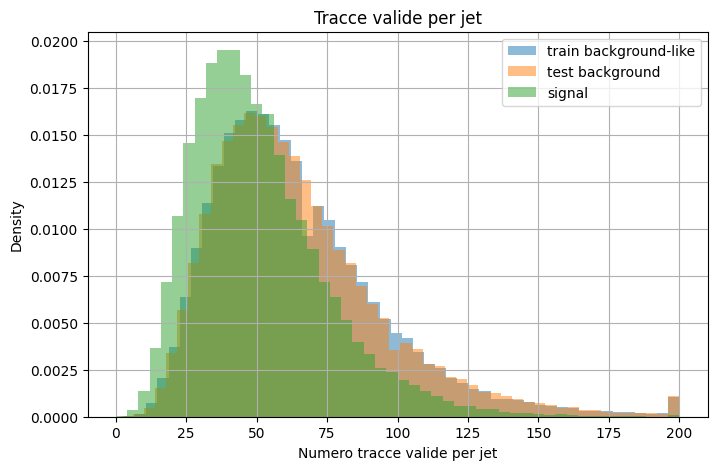

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(mask_train.sum(axis=1), bins=50, density=True, alpha=0.5, label="train background-like")
plt.hist(mask_bg.sum(axis=1), bins=50, density=True, alpha=0.5, label="test background")
plt.hist(mask_sig_eval.sum(axis=1), bins=50, density=True, alpha=0.5, label="signal")
plt.xlabel("Numero tracce valide per jet")
plt.ylabel("Density")
plt.title("Tracce valide per jet")
plt.legend()
plt.grid(True)
plt.show()

## 9. Dataset PyTorch

In [9]:
class JetGraphDataset(Dataset):
    def __init__(self, X_jets, X_tracks, mask):
        self.X_jets = torch.from_numpy(X_jets).float()
        self.X_tracks = torch.from_numpy(X_tracks).float()
        self.mask = torch.from_numpy(mask).bool()

    def __len__(self):
        return self.X_jets.shape[0]

    def __getitem__(self, idx):
        return self.X_jets[idx], self.X_tracks[idx], self.mask[idx]


full_dataset = JetGraphDataset(X_jets_train, X_tracks_train, mask_train)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Batch size:", batch_size)

Train: 80000
Validation: 20000
Batch size: 256


## 10. kNN su tracce valide

In [10]:
def knn_indices_from_coords(x_tracks, mask, coord_indices, k=8):
    """
    x_tracks: (B, N, F)
    mask: (B, N), bool
    coord_indices: indici delle coordinate da usare, tipicamente deta/dphi
    return: knn_idx (B, N, k)
    """
    coords = x_tracks[:, :, coord_indices]  # (B, N, C)

    # Distanze euclidee nello spazio delle coordinate scelte.
    # torch.cdist: (B, N, N)
    dist = torch.cdist(coords, coords, p=2)

    B, N, _ = dist.shape

    # Escludi self-neighbor
    eye = torch.eye(N, device=dist.device, dtype=torch.bool).unsqueeze(0)
    dist = dist.masked_fill(eye, 1e9)

    # Escludi nodi invalidi come possibili vicini
    invalid_neighbor = (~mask).unsqueeze(1).expand(B, N, N)
    dist = dist.masked_fill(invalid_neighbor, 1e9)

    # Per nodi invalidi, l'indice non importa, poi verranno mascherati
    k_eff = min(k, N - 1)
    knn_idx = torch.topk(dist, k=k_eff, dim=-1, largest=False).indices

    return knn_idx

## 11. Layer EdgeConv semplice

In [11]:
class EdgeConvBlock(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim=64, k=8):
        super().__init__()

        self.k = k

        self.mlp = nn.Sequential(
            nn.Linear(2 * in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
            nn.ReLU(),
        )

        self.residual = None
        if in_dim != out_dim:
            self.residual = nn.Linear(in_dim, out_dim)

    def forward(self, h, knn_idx, mask):
        """
        h: (B, N, D)
        knn_idx: (B, N, k)
        mask: (B, N)
        """
        B, N, D = h.shape
        k = knn_idx.shape[-1]

        idx_expanded = knn_idx.unsqueeze(-1).expand(B, N, k, D)
        h_expanded = h.unsqueeze(1).expand(B, N, N, D)
        h_neighbors = torch.gather(h_expanded, dim=2, index=idx_expanded)

        h_i = h.unsqueeze(2).expand(B, N, k, D)
        edge_input = torch.cat([h_i, h_neighbors - h_i], dim=-1)

        messages = self.mlp(edge_input)  # (B, N, k, out_dim)

        # Max aggregation sui vicini
        h_new = messages.max(dim=2).values  # (B, N, out_dim)

        if self.residual is not None:
            h_res = self.residual(h)
        else:
            h_res = h

        h_new = h_new + h_res

        # Azzeriamo nodi invalidi
        h_new = h_new * mask.unsqueeze(-1)

        return h_new

## 12. GNN Autoencoder

In [12]:
class JetConstituentGNNAE(nn.Module):
    def __init__(
        self,
        n_track_features,
        n_jet_features,
        coord_indices,
        k=8,
        node_dim=64,
        latent_dim=64,
    ):
        super().__init__()

        self.n_track_features = n_track_features
        self.n_jet_features = n_jet_features
        self.coord_indices = coord_indices
        self.k = k

        self.node_init = nn.Sequential(
            nn.Linear(n_track_features, node_dim),
            nn.ReLU(),
            nn.Linear(node_dim, node_dim),
            nn.ReLU(),
        )

        self.edge1 = EdgeConvBlock(node_dim, node_dim, hidden_dim=node_dim, k=k)
        self.edge2 = EdgeConvBlock(node_dim, node_dim, hidden_dim=node_dim, k=k)
        self.edge3 = EdgeConvBlock(node_dim, node_dim, hidden_dim=node_dim, k=k)

        pooled_dim = 2 * node_dim  # mean + max

        self.global_encoder = nn.Sequential(
            nn.Linear(pooled_dim + n_jet_features, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU(),
        )

        self.jet_decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, n_jet_features),
        )

        self.track_decoder = nn.Sequential(
            nn.Linear(node_dim + latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, n_track_features),
        )

    def masked_pool(self, h, mask):
        mask_f = mask.unsqueeze(-1).float()

        # mean pooling
        denom = mask_f.sum(dim=1).clamp(min=1.0)
        mean_pool = (h * mask_f).sum(dim=1) / denom

        # max pooling
        h_for_max = h.masked_fill(~mask.unsqueeze(-1), -1e9)
        max_pool = h_for_max.max(dim=1).values
        max_pool = torch.where(torch.isfinite(max_pool), max_pool, torch.zeros_like(max_pool))

        return torch.cat([mean_pool, max_pool], dim=1)

    def forward(self, x_jets, x_tracks, mask):
        knn_idx = knn_indices_from_coords(
            x_tracks=x_tracks,
            mask=mask,
            coord_indices=self.coord_indices,
            k=self.k,
        )

        h = self.node_init(x_tracks)
        h = h * mask.unsqueeze(-1)

        h = self.edge1(h, knn_idx, mask)
        h = self.edge2(h, knn_idx, mask)
        h = self.edge3(h, knn_idx, mask)

        pooled = self.masked_pool(h, mask)
        global_input = torch.cat([pooled, x_jets], dim=1)

        z = self.global_encoder(global_input)

        reco_jets = self.jet_decoder(z)

        B, N, D = h.shape
        z_nodes = z.unsqueeze(1).expand(B, N, z.shape[-1])
        track_decoder_input = torch.cat([h, z_nodes], dim=-1)

        reco_tracks = self.track_decoder(track_decoder_input)
        reco_tracks = reco_tracks * mask.unsqueeze(-1)

        return reco_jets, reco_tracks, z

## 13. Loss mascherata

In [13]:
def masked_track_mse(reco_tracks, x_tracks, mask):
    mask_f = mask.unsqueeze(-1).float()
    diff2 = (reco_tracks - x_tracks) ** 2
    diff2 = diff2 * mask_f

    denom = mask_f.sum() * x_tracks.shape[-1]
    denom = denom.clamp(min=1.0)

    return diff2.sum() / denom


def jet_mse(reco_jets, x_jets):
    return torch.mean((reco_jets - x_jets) ** 2)


def gnn_ae_loss(reco_jets, reco_tracks, x_jets, x_tracks, mask, jet_weight=1.0, track_weight=1.0):
    loss_jets = jet_mse(reco_jets, x_jets)
    loss_tracks = masked_track_mse(reco_tracks, x_tracks, mask)
    loss = jet_weight * loss_jets + track_weight * loss_tracks
    return loss, loss_jets, loss_tracks

## 14. Training

In [14]:
n_track_features = X_tracks_train.shape[-1]
n_jet_features = X_jets_train.shape[-1]

k_neighbors = 8
node_dim = 64
latent_dim = 64
jet_weight = 1.0
track_weight = 1.0

model = JetConstituentGNNAE(
    n_track_features=n_track_features,
    n_jet_features=n_jet_features,
    coord_indices=coord_indices,
    k=k_neighbors,
    node_dim=node_dim,
    latent_dim=latent_dim,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

print(model)

JetConstituentGNNAE(
  (node_init): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
  )
  (edge1): EdgeConvBlock(
    (mlp): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
    )
  )
  (edge2): EdgeConvBlock(
    (mlp): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
    )
  )
  (edge3): EdgeConvBlock(
    (mlp): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
    )
  )
  (global_encoder): Sequential(
    (0): Linear(in_features=142, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_feature

In [18]:
def evaluate_model(model, loader):
    model.eval()

    total_loss = 0.0
    total_jet_loss = 0.0
    total_track_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for x_jets, x_tracks, mask in loader:
            x_jets = x_jets.to(device, non_blocking=True)
            x_tracks = x_tracks.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)

            reco_jets, reco_tracks, _ = model(x_jets, x_tracks, mask)

            loss, loss_jets, loss_tracks = gnn_ae_loss(
                reco_jets,
                reco_tracks,
                x_jets,
                x_tracks,
                mask,
                jet_weight=jet_weight,
                track_weight=track_weight,
            )

            bs = x_jets.shape[0]
            total_loss += loss.item() * bs
            total_jet_loss += loss_jets.item() * bs
            total_track_loss += loss_tracks.item() * bs
            total_items += bs

    return (
        total_loss / total_items,
        total_jet_loss / total_items,
        total_track_loss / total_items,
    )

In [ ]:
n_epochs = 50

train_losses = []
val_losses = []
train_jet_losses = []
train_track_losses = []
val_jet_losses = []
val_track_losses = []

for epoch in range(n_epochs):
    model.train()

    total_loss = 0.0
    total_jet_loss = 0.0
    total_track_loss = 0.0
    total_items = 0

    for x_jets, x_tracks, mask in train_loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        optimizer.zero_grad()

        reco_jets, reco_tracks, _ = model(x_jets, x_tracks, mask)
        loss, loss_jets, loss_tracks = gnn_ae_loss(
            reco_jets,
            reco_tracks,
            x_jets,
            x_tracks,
            mask,
            jet_weight=jet_weight,
            track_weight=track_weight,
        )

        loss.backward()
        optimizer.step()

        bs = x_jets.shape[0]
        total_loss += loss.item() * bs
        total_jet_loss += loss_jets.item() * bs
        total_track_loss += loss_tracks.item() * bs
        total_items += bs

    train_loss = total_loss / total_items
    train_jet_loss = total_jet_loss / total_items
    train_track_loss = total_track_loss / total_items

    val_loss, val_jet_loss, val_track_loss = evaluate_model(model, val_loader)

    train_losses.append(train_loss)
    train_jet_losses.append(train_jet_loss)
    train_track_losses.append(train_track_loss)

    val_losses.append(val_loss)
    val_jet_losses.append(val_jet_loss)
    val_track_losses.append(val_track_loss)

    print(
        f"Epoch {epoch+1:02d}/{n_epochs} | "
        f"train={train_loss:.6f} jet={train_jet_loss:.6f} track={train_track_loss:.6f} | "
        f"val={val_loss:.6f} jet={val_jet_loss:.6f} track={val_track_loss:.6f}"
    )

Epoch 01/50 | train=0.005812 jet=0.003135 track=0.002677 | val=0.004330 jet=0.002211 track=0.002119
Epoch 02/50 | train=0.004254 jet=0.002230 track=0.002024 | val=0.003861 jet=0.002072 track=0.001789
Epoch 03/50 | train=0.003526 jet=0.001886 track=0.001640 | val=0.003425 jet=0.002087 track=0.001337
Epoch 04/50 | train=0.003079 jet=0.001615 track=0.001464 | val=0.002384 jet=0.001422 track=0.000961


## 15. Plot loss

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="train total")
plt.plot(val_losses, label="val total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GNN AE total loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_jet_losses, label="train jet")
plt.plot(val_jet_losses, label="val jet")
plt.plot(train_track_losses, label="train track")
plt.plot(val_track_losses, label="val track")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss components")
plt.legend()
plt.grid(True)
plt.show()

## 16. Anomaly score

In [ ]:
class JetGraphEvalDataset(Dataset):
    def __init__(self, X_jets, X_tracks, mask):
        self.X_jets = torch.from_numpy(X_jets).float()
        self.X_tracks = torch.from_numpy(X_tracks).float()
        self.mask = torch.from_numpy(mask).bool()

    def __len__(self):
        return self.X_jets.shape[0]

    def __getitem__(self, idx):
        return self.X_jets[idx], self.X_tracks[idx], self.mask[idx]


def compute_gnn_scores(model, X_jets, X_tracks, mask, batch_size=512):
    dataset = JetGraphEvalDataset(X_jets, X_tracks, mask)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()

    total_scores = []
    jet_scores = []
    track_scores = []

    with torch.no_grad():
        for x_jets, x_tracks, mask_batch in loader:
            x_jets = x_jets.to(device, non_blocking=True)
            x_tracks = x_tracks.to(device, non_blocking=True)
            mask_batch = mask_batch.to(device, non_blocking=True)

            reco_jets, reco_tracks, _ = model(x_jets, x_tracks)

            jet_error = ((reco_jets - x_jets) ** 2).mean(dim=1)

            diff2_tracks = (reco_tracks - x_tracks) ** 2
            diff2_tracks = diff2_tracks * mask_batch.unsqueeze(-1)

            track_error_sum = diff2_tracks.sum(dim=(1, 2))
            track_denom = mask_batch.sum(dim=1) * x_tracks.shape[-1]
            track_denom = track_denom.clamp(min=1)

            track_error = track_error_sum / track_denom

            total_score = jet_weight * jet_error + track_weight * track_error

            total_scores.append(total_score.cpu().numpy())
            jet_scores.append(jet_error.cpu().numpy())
            track_scores.append(track_error.cpu().numpy())

    return np.concatenate(total_scores), np.concatenate(jet_scores), np.concatenate(track_scores)

In [ ]:
scores_train, scores_train_jets, scores_train_tracks = compute_gnn_scores(
    model,
    X_jets_train,
    X_tracks_train,
    mask_train,
    batch_size=512,
)

scores_bg, scores_bg_jets, scores_bg_tracks = compute_gnn_scores(
    model,
    X_jets_bg,
    X_tracks_bg,
    mask_bg,
    batch_size=512,
)

scores_sig, scores_sig_jets, scores_sig_tracks = compute_gnn_scores(
    model,
    X_jets_sig_eval,
    X_tracks_sig_eval,
    mask_sig_eval,
    batch_size=512,
)

print("Total score")
print("train mean/median:", scores_train.mean(), np.median(scores_train))
print("bg mean/median:", scores_bg.mean(), np.median(scores_bg))
print("sig mean/median:", scores_sig.mean(), np.median(scores_sig))

print("\nJet score")
print("bg mean/median:", scores_bg_jets.mean(), np.median(scores_bg_jets))
print("sig mean/median:", scores_sig_jets.mean(), np.median(scores_sig_jets))

print("\nTrack score")
print("bg mean/median:", scores_bg_tracks.mean(), np.median(scores_bg_tracks))
print("sig mean/median:", scores_sig_tracks.mean(), np.median(scores_sig_tracks))

## 17. ROC/AUC

In [ ]:
def evaluate_binary_scores(bg_scores, sig_scores, title):
    y_true = np.concatenate([
        np.zeros_like(bg_scores),
        np.ones_like(sig_scores),
    ])

    y_score = np.concatenate([
        bg_scores,
        sig_scores,
    ])

    auc = roc_auc_score(y_true, y_score)
    auc_inv = roc_auc_score(y_true, -y_score)
    best_auc = max(auc, auc_inv)

    print("\n" + title)
    print("AUC:", auc)
    print("AUC inverted:", auc_inv)
    print("Best AUC:", best_auc)

    if auc_inv > auc:
        plot_score = -y_score
        label = f"AUC inverted = {auc_inv:.3f}"
    else:
        plot_score = y_score
        label = f"AUC = {auc:.3f}"

    fpr, tpr, _ = roc_curve(y_true, plot_score)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=label)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return auc, auc_inv, best_auc


def plot_score_distribution(bg_scores, sig_scores, title):
    plt.figure(figsize=(8, 5))
    plt.hist(bg_scores, bins=100, density=True, alpha=0.6, label="background")
    plt.hist(sig_scores, bins=100, density=True, alpha=0.6, label="signal")
    plt.yscale("log")
    plt.xlabel("score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_score_distribution(scores_bg, scores_sig, "GNN AE total score")
auc_total, auc_total_inv, best_auc_total = evaluate_binary_scores(scores_bg, scores_sig, "GNN AE total score ROC")

plot_score_distribution(scores_bg_jets, scores_sig_jets, "GNN AE jet reconstruction score")
auc_jets, auc_jets_inv, best_auc_jets = evaluate_binary_scores(scores_bg_jets, scores_sig_jets, "GNN AE jet score ROC")

plot_score_distribution(scores_bg_tracks, scores_sig_tracks, "GNN AE track reconstruction score")
auc_tracks, auc_tracks_inv, best_auc_tracks = evaluate_binary_scores(scores_bg_tracks, scores_sig_tracks, "GNN AE track score ROC")

## 18. Controllo train vs test background

In [ ]:
def compare_train_bg_sig(train_scores, bg_scores, sig_scores, title):
    plt.figure(figsize=(8, 5))
    plt.hist(train_scores, bins=100, density=True, alpha=0.5, label="train background-like")
    plt.hist(bg_scores, bins=100, density=True, alpha=0.5, label="test background")
    plt.hist(sig_scores, bins=100, density=True, alpha=0.5, label="signal")
    plt.yscale("log")
    plt.xlabel("score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    y = np.concatenate([
        np.zeros_like(train_scores),
        np.ones_like(bg_scores),
    ])

    s = np.concatenate([
        train_scores,
        bg_scores,
    ])

    auc_tb = roc_auc_score(y, s)
    auc_tb_inv = roc_auc_score(y, -s)

    print("Train vs test background AUC:", auc_tb)
    print("Train vs test background AUC inverted:", auc_tb_inv)
    print("Best train-vs-test-background AUC:", max(auc_tb, auc_tb_inv))


compare_train_bg_sig(scores_train, scores_bg, scores_sig, "GNN AE: train vs background vs signal")

## 19. Diagnostica supervisionata semplice su embedding latente

In [ ]:
def compute_latent_embeddings(model, X_jets, X_tracks, mask, batch_size=512):
    dataset = JetGraphEvalDataset(X_jets, X_tracks, mask)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()
    embeddings = []

    with torch.no_grad():
        for x_jets, x_tracks, mask_batch in loader:
            x_jets = x_jets.to(device, non_blocking=True)
            x_tracks = x_tracks.to(device, non_blocking=True)
            mask_batch = mask_batch.to(device, non_blocking=True)

            _, _, z = model(x_jets, x_tracks, mask_batch)
            embeddings.append(z.cpu().numpy())

    return np.concatenate(embeddings, axis=0)


Z_bg = compute_latent_embeddings(model, X_jets_bg, X_tracks_bg, mask_bg)
Z_sig = compute_latent_embeddings(model, X_jets_sig_eval, X_tracks_sig_eval, mask_sig_eval)

print("Z_bg:", Z_bg.shape)
print("Z_sig:", Z_sig.shape)

X_clf = np.concatenate([Z_bg, Z_sig], axis=0)
y_clf = np.concatenate([
    np.zeros(Z_bg.shape[0], dtype=np.int64),
    np.ones(Z_sig.shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf,
    y_clf,
    test_size=0.3,
    random_state=42,
    stratify=y_clf,
)

clf = LogisticRegression(max_iter=3000)
clf.fit(X_tr, y_tr)

proba = clf.predict_proba(X_te)[:, 1]
auc_latent_logreg = roc_auc_score(y_te, proba)

print("Supervised logistic regression AUC on GNN latent embeddings:", auc_latent_logreg)

## 20. Salvataggio

In [ ]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "jet_feature_names": jet_feature_names,
        "track_feature_names": track_feature_names,
        "coord_indices": coord_indices,
        "coord_feature_names": coord_feature_names,
        "n_track_features": n_track_features,
        "n_jet_features": n_jet_features,
        "k_neighbors": k_neighbors,
        "node_dim": node_dim,
        "latent_dim": latent_dim,
        "jet_weight": jet_weight,
        "track_weight": track_weight,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_jet_losses": train_jet_losses,
        "val_jet_losses": val_jet_losses,
        "train_track_losses": train_track_losses,
        "val_track_losses": val_track_losses,
        "best_auc_total": best_auc_total,
        "best_auc_jets": best_auc_jets,
        "best_auc_tracks": best_auc_tracks,
        "auc_latent_logreg": auc_latent_logreg,
    },
    OUTPUT_DIR / "gnn_constituent_autoencoder.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "gnn_constituent_scores.npz",
    scores_train=scores_train,
    scores_bg=scores_bg,
    scores_sig=scores_sig,
    scores_train_jets=scores_train_jets,
    scores_bg_jets=scores_bg_jets,
    scores_sig_jets=scores_sig_jets,
    scores_train_tracks=scores_train_tracks,
    scores_bg_tracks=scores_bg_tracks,
    scores_sig_tracks=scores_sig_tracks,
    Z_bg=Z_bg,
    Z_sig=Z_sig,
    jet_feature_names=np.array(jet_feature_names, dtype=object),
    track_feature_names=np.array(track_feature_names, dtype=object),
    auc_total=np.array(auc_total, dtype=np.float32),
    auc_total_inv=np.array(auc_total_inv, dtype=np.float32),
    best_auc_total=np.array(best_auc_total, dtype=np.float32),
    auc_jets=np.array(auc_jets, dtype=np.float32),
    best_auc_jets=np.array(best_auc_jets, dtype=np.float32),
    auc_tracks=np.array(auc_tracks, dtype=np.float32),
    best_auc_tracks=np.array(best_auc_tracks, dtype=np.float32),
    auc_latent_logreg=np.array(auc_latent_logreg, dtype=np.float32),
)

config = {
    "USE_DISPLACED_PT_FRACTION": USE_DISPLACED_PT_FRACTION,
    "EVAL_ONLY_TRUE_DISPLACED_SIGNAL": EVAL_ONLY_TRUE_DISPLACED_SIGNAL,
    "jet_features": jet_feature_names,
    "track_features": track_feature_names,
    "coord_feature_names": coord_feature_names,
    "coord_indices": coord_indices,
    "k_neighbors": k_neighbors,
    "node_dim": node_dim,
    "latent_dim": latent_dim,
    "batch_size": batch_size,
    "n_epochs": n_epochs,
    "jet_weight": jet_weight,
    "track_weight": track_weight,
    "processed_files": {k: str(v) for k, v in processed_files.items()},
    "best_auc_total": float(best_auc_total),
    "best_auc_jets": float(best_auc_jets),
    "best_auc_tracks": float(best_auc_tracks),
    "auc_latent_logreg": float(auc_latent_logreg),
}

with open(OUTPUT_DIR / "gnn_constituent_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:")
print(OUTPUT_DIR / "gnn_constituent_autoencoder.pt")
print(OUTPUT_DIR / "gnn_constituent_scores.npz")
print(OUTPUT_DIR / "gnn_constituent_config.json")

## Note

Cose da controllare nei risultati:

1. **Train vs test background AUC**  
   Se è molto sopra 0.5, il test background non è distribuito come il training background.

2. **Jet score vs track score**  
   Se il jet score domina, il modello sta sfruttando molto le feature globali del jet.  
   Se il track score domina, sta usando davvero i constituents.

3. **Latent logistic regression AUC**  
   È una diagnostica supervisionata: non è il risultato anomaly detection, ma dice se l'embedding GNN contiene informazione discriminante.

4. **Batch size**  
   Se la GPU va out-of-memory, riduci `batch_size = 128` o `64`.

5. **k_neighbors**  
   Puoi provare `k_neighbors = 4`, `8`, `16`.